# Asset Allocation Model

pg. 161 from "Trading Evolved" by Andreas F. Clenow

"The rules of this first ETF model are the following.  We will use five ETFs to allocate our assets to.  Each ETF will have a target weight, and at the beginning of each month we will reset the allocation to this target weight."

25%  SPY - S&P500 Index Tracker ETF
30%  TLT - 20 Year Treasury ETF
30%  IEF - 7-10 Year Treasury ETF
7.5% GLD - Gold Tracker ETF
7.5% DBC - General Commodity Tracker ETF

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import datetime
import math
from talib.abstract import *
from datetime import datetime, timedelta, date
#import numpy as np

import sys
sys.path.append('/Users/moilanen/sbx/paragon/lib')
sys.path.append('.')

import pinkfish as pf

# format price data
pd.options.display.float_format = '{:0.2f}'.format

%matplotlib inline

In [2]:
# set size of inline plots
'''note: rcParams can't be in same cell as import matplotlib
   or %matplotlib inline
   
   %matplotlib notebook: will lead to interactive plots embedded within
   the notebook, you can zoom and resize the figure
   
   %matplotlib inline: only draw static images in the notebook
'''
plt.rcParams["figure.figsize"] = (10, 7)

Some global data

In [71]:
# symbols = ['DRIV', 'DWSH', 'EPI', 'EUFN', 'FDN', 'FINX', 'HDGE', 'IAI', 'ICLN', 'JETS', 'KBE', 'KWEB', 'LIT', 'MJ', 'PDBC', 'PSP', 'QQQ', 'SH', 'SMH', 'XBI', 'XLB', 'XLV', 'XOP', 'XSW', 'XLY']
symbols = ['XLU', 'XLV', 'XLRE', 'XLC', 'XLB', 'XLF', 'XLP', 'XLI', 'XLY', 'XLK', 'XLE']
# symbols = ['XLU', 'XLV', 'XLRE', 'XLC', 'XLB', 'XLF', 'XLP', 'XLI', 'XLY', 'XLK', 'XLE', 'MINT']

capital = 100000
margin = pf.Margin.CASH

lookback = 14
num_days = 500 + lookback
start = date.today() - timedelta(days = math.ceil((num_days/(5/7))))
end = datetime.now()

use_cache = True

In [72]:
from polygon import RESTClient
from dateutil import tz
def aggregates_to_df(resp):
    epoch = datetime(1601, 1, 1)
    df = pd.DataFrame(resp.results)
#     tz_ = tz.gettz('America/New_York')
    tz_ = tz.gettz('UTC')

    df.set_index(df['t'].apply(lambda x: datetime.fromtimestamp(x / 1000, tz=tz_)), inplace=True)
    df.rename(columns={"v": "volume", "o": "open", "c": "close", "h": "high", "l": "low"}, inplace=True)
    if 't' in df:
        df.drop(['t'], axis=1, inplace=True)
    if 'n' in df:
        df.drop(['n'], axis=1, inplace=True)

#     del df.index.name

    return df

def history(symbol, start_date, timespan = 'day'):
    date_format = "%Y-%m-%d"
    
    end_date = date.today() + timedelta(days = 7) # Polygon is exclusive on dates and must extend for a week
    client = RESTClient('WeYC_RTF_nZg3S_UKGI68lvNZ__8l6YM09p_Rg')
    multiplier = 1

    try:
        resp = client.stocks_equities_aggregates(symbol, multiplier, timespan, start_date.strftime(date_format), end_date.strftime(date_format))
    except Exception as e:
        print("[history_aggregate()]: Polygon connection error: %s" % (str(e)))

    if resp.status != 'OK':
        raise ValueError("Polygon history_aggregate response not OK: %s" % (resp['status']))
        
    if resp.results == None or len(resp.results) == 0:
        raise ValueError("Polygon history_aggregate results are empty")
        
    df = aggregates_to_df(resp)
    
    return df



In [73]:
# Pull Data

ohlcvs = {}

# polygon = Polygon()
    
for stock in symbols:

    ohlcv = history(stock, start)
#     ohlcv = ohlcv = polygon.history_aggregate(stock, num_days, '1d', start, after_hours = False)
    print("------ %s ------: %d" % (stock, len(ohlcv)))
    
    ohlcvs[stock] = ohlcv


------ XLU ------: 497
------ XLV ------: 497
------ XLRE ------: 497
------ XLC ------: 497
------ XLB ------: 497
------ XLF ------: 497
------ XLP ------: 497
------ XLI ------: 497
------ XLY ------: 497
------ XLK ------: 497
------ XLE ------: 497


In [74]:
print(ohlcvs)
df = pd.DataFrame(index=ohlcv.index)
for stock, ohlcv in ohlcvs.items():
#     print("%s" % (str(index)))
    df["%s_high" % stock] = ohlcv['high']
    df["%s_low" % stock] = ohlcv['low']
    df["%s_close" % stock] = ohlcv['close']

df = df.set_index(pd.DatetimeIndex(df.index.date))
df.fillna(method='ffill', inplace=True)
# df

{'XLU':                                volume    vw  open  close  high   low
t                                                                   
2019-02-12 05:00:00+00:00 14770832.00 55.78 55.67  55.79 56.07 55.35
2019-02-13 05:00:00+00:00 13408245.00 55.56 55.62  55.63 55.77 55.40
2019-02-14 05:00:00+00:00 19114956.00 55.61 55.67  55.54 55.83 55.34
2019-02-15 05:00:00+00:00  9362196.00 55.68 55.72  55.71 55.92 55.51
2019-02-19 05:00:00+00:00 14516077.00 55.93 55.75  56.04 56.10 55.58
...                               ...   ...   ...    ...   ...   ...
2021-01-26 05:00:00+00:00  9755209.00 63.50 64.01  63.46 64.08 63.20
2021-01-27 05:00:00+00:00 19662566.00 62.43 62.95  61.75 63.41 61.47
2021-01-28 05:00:00+00:00 12750564.00 62.91 61.96  62.49 63.44 61.80
2021-01-29 05:00:00+00:00 13912220.00 62.26 62.17  62.15 62.78 61.76
2021-02-01 05:00:00+00:00  8077950.00 62.53 62.55  62.45 63.01 61.93

[497 rows x 6 columns], 'XLV':                                volume     vw   open  close   hi

In [75]:
# fetch timeseries
portfolio = pf.Portfolio()
ts = portfolio.fetch_timeseries(symbols, start, end, use_cache=use_cache)
ts = df
# print(df)
# print(ts)

In [76]:
# add calendar columns
ts = portfolio.calendar(ts)

In [77]:
ts, start = portfolio.finalize_timeseries(ts, start)
# ts
# ts[ts.isna().any(axis=1)]

In [78]:
portfolio.init_trade_logs(ts, capital, margin)
pf.TradeLog.instance

{'XLU': <pinkfish.trade.TradeLog at 0x1780ba2d0>,
 'XLV': <pinkfish.trade.TradeLog at 0x1780ba1d0>,
 'XLRE': <pinkfish.trade.TradeLog at 0x1780ba310>,
 'XLC': <pinkfish.trade.TradeLog at 0x1780ba190>,
 'XLB': <pinkfish.trade.TradeLog at 0x1780ba350>,
 'XLF': <pinkfish.trade.TradeLog at 0x1780ba050>,
 'XLP': <pinkfish.trade.TradeLog at 0x1780ba150>,
 'XLI': <pinkfish.trade.TradeLog at 0x1780ba0d0>,
 'XLY': <pinkfish.trade.TradeLog at 0x1780ba290>,
 'XLK': <pinkfish.trade.TradeLog at 0x1780ba090>,
 'XLE': <pinkfish.trade.TradeLog at 0x1780ba250>}

# HRP

In [79]:
len(ts)

496

In [81]:
from mlfinlab.portfolio_optimization.hrp import HierarchicalRiskParity
from mlfinlab.portfolio_optimization.herc import HierarchicalEqualRiskContribution

from IPython.core.debugger import Pdb
from scipy.cluster.hierarchy import dendrogram
hrp = HierarchicalRiskParity()
herc = HierarchicalEqualRiskContribution()

# print(str(ts))
df = pd.DataFrame(index=ohlcv.index)

# Put Stocks into a DataFrame that HRP likes
for stock in symbols:
    df[stock] = ohlcvs[stock]['close']
df = df.set_index(pd.DatetimeIndex(df.index.date))

# print(str(df))
startdate_benchmark = False

for i in range(lookback, len(df)):
    df_tmp = df.iloc[i-lookback:i].dropna(axis=1)
    
#     print(str(df_tmp.iloc[-1].index))
    if False:
        res = hrp.allocate(np.array(df_tmp.columns.tolist()), df_tmp, linkage='ward')
        weights = hrp.weights.T
    else:
        risk_measure = 'conditional_drawdown_risk'
        risk_measure = 'standard_deviation'
        risk_measure = 'variance'
#         risk_measure = 'equal_weighting'
#         risk_measure = 'expected_shortfall'

        res = herc.allocate(asset_names=np.array(df_tmp.columns.tolist()), asset_prices=df_tmp, risk_measure=risk_measure, linkage='ward')
        weights = herc.weights.T

    weights.columns = ['weight']
    
    date = df_tmp.iloc[-1].name
    
    if startdate_benchmark is False:
        startdate_benchmark = date
    print("[%d] Date: %s" % (i, date))

    row = ts.iloc[i]
    
    for symbol, weight in weights.iterrows():
        price = df.iloc[i][symbol]
        wt = weight['weight']
        if i == (num_days == 1):
            wt = 0.0
        print("[%s]: %f %s" % (symbol, price, wt))

        portfolio.adjust_percent(date, price, wt, symbol, row)
        
    portfolio.record_daily_balance(date, row)
    
print(str(weights))
#     print(str(type(weights)))
#     print(weights.index.tolist())

[14] Date: 2019-03-04 00:00:00
[XLRE]: 34.910000 0.3759352265047308
[XLU]: 57.160000 0.1174832354069123
[XLP]: 54.110000 0.06975912605063843
[XLB]: 54.970000 0.06004661179255942
[XLF]: 26.420000 0.05945551519564402
[XLI]: 75.580000 0.13107548101085026
[XLY]: 111.030000 0.06789084120766685
[XLE]: 66.350000 0.016618351076570337
[XLC]: 46.630000 0.039844313740995875
[XLV]: 91.640000 0.014387624320378808
[XLK]: 70.860000 0.047503673693052834
[15] Date: 2019-03-05 00:00:00
[XLRE]: 34.820000 0.4023719024490558
[XLU]: 57.160000 0.11752734379967025
[XLP]: 54.030000 0.06607949783569503
[XLB]: 55.090000 0.055432765192229685
[XLF]: 26.250000 0.05630892066834561
[XLI]: 74.870000 0.11659817642650475
[XLC]: 46.610000 0.08434049125150515
[XLV]: 90.300000 0.011970653640589949
[XLK]: 70.490000 0.035679031406884776
[XLY]: 110.510000 0.04361603998241588
[XLE]: 65.510000 0.010075177347103111
[16] Date: 2019-03-06 00:00:00
[XLP]: 53.680000 0.3549183518066181
[XLU]: 57.350000 0.27499574157414625
[XLRE]: 34.

[34] Date: 2019-04-01 00:00:00
[XLC]: 47.730000 0.1697546637062495
[XLV]: 91.680000 0.040656058708703084
[XLF]: 26.320000 0.01331112160230455
[XLE]: 66.530000 0.01920104556067091
[XLK]: 75.270000 0.019066595143268188
[XLI]: 76.550000 0.020342887753766838
[XLB]: 56.520000 0.01975076533051127
[XLY]: 115.080000 0.03564930934579801
[XLU]: 57.850000 0.2224018023082342
[XLRE]: 36.420000 0.14171782703244012
[XLP]: 55.460000 0.29814792350805336
[35] Date: 2019-04-02 00:00:00
[XLE]: 65.890000 0.06068075365079653
[XLF]: 26.400000 0.044069275345201595
[XLB]: 57.260000 0.06779599779680412
[XLI]: 76.320000 0.06781404501140643
[XLC]: 47.910000 0.10519174003769605
[XLV]: 91.560000 0.1330745059753427
[XLY]: 115.890000 0.12096219510305414
[XLK]: 75.880000 0.06264292019405691
[XLU]: 57.760000 0.2096925369827645
[XLRE]: 36.380000 0.04632780843978672
[XLP]: 55.190000 0.08174822146309028
[36] Date: 2019-04-03 00:00:00
[XLE]: 66.440000 0.0480236402631534
[XLF]: 26.560000 0.03535415439810447
[XLI]: 76.790000

[53] Date: 2019-04-29 00:00:00
[XLU]: 58.710000 0.2620559417055364
[XLRE]: 36.030000 0.06689599910185715
[XLV]: 89.260000 0.05440612911398925
[XLC]: 50.070000 0.3074635872834348
[XLK]: 78.710000 0.07706028040802285
[XLE]: 66.110000 0.015168419558229777
[XLP]: 57.710000 0.14399873623188297
[XLF]: 28.020000 0.015173657526962144
[XLY]: 120.070000 0.03233502084253166
[XLB]: 57.450000 0.015695927659167653
[XLI]: 78.010000 0.00974630056838539
[54] Date: 2019-04-30 00:00:00
[XLV]: 89.100000 0.1367075618271552
[XLU]: 58.110000 0.46843549769150794
[XLRE]: 36.030000 0.19337495400834115
[XLC]: 49.810000 0.024024286065217365
[XLK]: 78.510000 0.016861957561311567
[XLE]: 64.790000 0.003081075625241697
[XLP]: 57.000000 0.08919244940397782
[XLF]: 27.790000 0.014528355716235944
[XLY]: 118.610000 0.03089290413090089
[XLB]: 56.410000 0.013428454698423069
[XLI]: 77.500000 0.009472503271687404
[55] Date: 2019-05-01 00:00:00
[XLV]: 89.480000 0.1717200771639383
[XLU]: 57.980000 0.27537900314061897
[XLRE]: 36

[73] Date: 2019-05-28 00:00:00
[XLC]: 47.720000 0.0691107069602497
[XLY]: 111.680000 0.1049863863845643
[XLK]: 72.660000 0.05793598837630092
[XLE]: 60.590000 0.0730597660909464
[XLB]: 53.260000 0.08268538344234824
[XLF]: 26.500000 0.09668387934754397
[XLI]: 72.770000 0.0986607890707455
[XLU]: 58.070000 0.25017901975349666
[XLRE]: 35.950000 0.08091379170636935
[XLV]: 87.430000 0.04053844407420268
[XLP]: 56.170000 0.045245844793232314
[74] Date: 2019-05-29 00:00:00
[XLC]: 47.830000 0.05552648549294371
[XLY]: 112.410000 0.08506201885999033
[XLK]: 73.110000 0.04798486034611609
[XLE]: 59.820000 0.060523597754332234
[XLB]: 53.350000 0.06951869916467988
[XLF]: 26.410000 0.07990386655268422
[XLI]: 73.050000 0.08159104672373696
[XLV]: 87.910000 0.12614680280877977
[XLP]: 56.410000 0.14495558194288904
[XLU]: 57.980000 0.10726289991651312
[XLRE]: 36.170000 0.14152414043733452
[75] Date: 2019-05-30 00:00:00
[XLC]: 47.090000 0.06734093855853614
[XLY]: 110.940000 0.09799961223939027
[XLK]: 71.890000

[93] Date: 2019-06-25 00:00:00
[XLU]: 59.320000 0.23494939447550514
[XLRE]: 36.350000 0.11007914467386277
[XLP]: 58.000000 0.2594008908342662
[XLF]: 26.970000 0.10530682643992985
[XLB]: 57.820000 0.10303856083059157
[XLI]: 76.540000 0.05884149932285286
[XLV]: 91.690000 0.08833617440168542
[XLE]: 63.450000 0.007399808154927734
[XLC]: 48.410000 0.010638319600065107
[XLY]: 118.120000 0.015611124865292507
[XLK]: 77.850000 0.006398256401020861
[94] Date: 2019-06-26 00:00:00
[XLV]: 92.330000 0.26890766131556654
[XLU]: 59.400000 0.11565187397943992
[XLRE]: 36.650000 0.10217347035638293
[XLP]: 58.110000 0.2480120894644914
[XLC]: 48.750000 0.10330439488756286
[XLB]: 58.010000 0.03740821839852221
[XLF]: 27.210000 0.03412685865075386
[XLY]: 118.860000 0.04230001664932964
[XLE]: 62.980000 0.013183673094483614
[XLI]: 76.610000 0.020031648775570583
[XLK]: 78.050000 0.014900094427896514
[95] Date: 2019-06-27 00:00:00
[XLV]: 92.640000 0.25508344286014534
[XLU]: 59.630000 0.1225798991014865
[XLRE]: 36.

...

[433] Date: 2020-10-28 00:00:00
[XLRE]: 34.370000 0.21510128615150484
[XLY]: 146.160000 0.13335444775334043
[XLC]: 60.220000 0.06741518424557233
[XLP]: 62.480000 0.21331741358206016
[XLK]: 113.370000 0.08042191542735369
[XLU]: 62.970000 0.09378312938033258
[XLV]: 101.690000 0.07266831543181447
[XLB]: 63.220000 0.050638089716697664
[XLI]: 75.960000 0.031436412604831564
[XLF]: 23.790000 0.029412025147018513
[XLE]: 28.560000 0.012451780559473866
[434] Date: 2020-10-29 00:00:00
[XLRE]: 34.150000 0.2786976952145964
[XLB]: 63.180000 0.05214925936068312
[XLI]: 75.870000 0.04135371580418967
[XLF]: 23.860000 0.044916796384969385
[XLE]: 28.720000 0.01498797794613187
[XLU]: 62.380000 0.15916246417712376
[XLV]: 101.660000 0.1287569747622929
[XLC]: 59.200000 0.032868905814457075
[XLK]: 110.860000 0.047672268317690905
[XLP]: 62.260000 0.12798553599186346
[XLY]: 142.970000 0.07144840622600146
[435] Date: 2020-10-30 00:00:00
[XLB]: 65.280000 0.22154097176007181
[XLI]: 77.920000 0.17577144880559006
[XL

[453] Date: 2020-11-25 00:00:00
[XLK]: 122.660000 0.45694298650765297
[XLC]: 65.630000 0.19760257828804326
[XLY]: 158.220000 0.18208335189038208
[XLF]: 28.470000 0.006863407271958718
[XLE]: 38.910000 0.0018874392859613428
[XLB]: 71.710000 0.019005472327733326
[XLI]: 88.820000 0.01791651837563334
[XLP]: 66.920000 0.09558131632808427
[XLU]: 63.760000 0.012014717706148058
[XLV]: 109.440000 0.007213725768318767
[XLRE]: 36.820000 0.002888486250083869
[454] Date: 2020-11-27 00:00:00
[XLI]: 88.030000 0.21407802750122612
[XLE]: 36.760000 0.029938660171035716
[XLB]: 70.990000 0.19416880643757434
[XLF]: 27.880000 0.1716884227876925
[XLK]: 123.480000 0.06539691069107767
[XLC]: 65.400000 0.12307394613333508
[XLY]: 157.260000 0.10525394064395853
[XLU]: 62.840000 0.02163061981227456
[XLP]: 66.910000 0.037197182499653474
[XLV]: 109.740000 0.023285017000525987
[XLRE]: 36.500000 0.014288466321646022
[455] Date: 2020-11-30 00:00:00
[XLF]: 28.310000 0.18047846913999654
[XLE]: 36.930000 0.0306759644713687

[473] Date: 2020-12-24 00:00:00
[XLF]: 29.090000 0.5655906244431389
[XLE]: 37.880000 0.12001928583751498
[XLK]: 130.520000 0.053319647370265046
[XLY]: 159.680000 0.03978966228439267
[XLU]: 61.480000 0.018405780585363792
[XLRE]: 36.200000 0.013273429603646159
[XLI]: 88.110000 0.025471704861127716
[XLV]: 111.750000 0.02998203050446939
[XLB]: 71.300000 0.01925593315415475
[XLC]: 67.450000 0.06357655121787992
[XLP]: 67.250000 0.051315350138046785
[474] Date: 2020-12-28 00:00:00
[XLC]: 67.390000 0.09002402106756408
[XLP]: 67.050000 0.11831647603924696
[XLY]: 159.730000 0.11501358127147228
[XLK]: 129.900000 0.04194696278678547
[XLU]: 61.470000 0.020026796912425253
[XLRE]: 35.920000 0.014101851980132698
[XLI]: 87.580000 0.13604797087674791
[XLV]: 112.280000 0.16965239350187647
[XLB]: 71.130000 0.10066295155759437
[XLF]: 28.990000 0.15774310545634948
[XLE]: 37.630000 0.036463888549804965
[475] Date: 2020-12-29 00:00:00
[XLF]: 29.120000 0.38279413587362515
[XLE]: 38.220000 0.09003367299031025
[

[493] Date: 2021-01-26 00:00:00
[XLB]: 70.820000 0.2496620573266841
[XLI]: 85.370000 0.3630428426179781
[XLF]: 29.000000 0.24728235676094665
[XLE]: 40.200000 0.035181753358560615
[XLU]: 61.750000 0.030857216045298785
[XLRE]: 37.050000 0.006524850188254843
[XLP]: 65.190000 0.021016138753415695
[XLV]: 114.340000 0.04037265445863142
[XLY]: 165.360000 0.002911286547350593
[XLC]: 67.910000 0.0013703530148608406
[XLK]: 131.500000 0.001778490928018444
[494] Date: 2021-01-27 00:00:00
[XLE]: 40.670000 0.04853007678071324
[XLF]: 29.540000 0.23662982576416428
[XLB]: 72.040000 0.22395266016488183
[XLI]: 86.640000 0.36362975522547764
[XLY]: 165.880000 0.02394215979465027
[XLC]: 68.150000 0.010407034221983311
[XLK]: 132.040000 0.022172163663820698
[XLU]: 62.490000 0.016875531165221253
[XLV]: 116.010000 0.026826509818062377
[XLRE]: 37.150000 0.007906247791886756
[XLP]: 65.440000 0.019128035609138186
[495] Date: 2021-01-28 00:00:00
[XLE]: 39.320000 0.08995836185807062
[XLF]: 28.950000 0.11361874253103

IndexError: single positional indexer is out-of-bounds

In [ ]:
# get logs
rlog, tlog, dbal = portfolio.get_logs()

In [ ]:
rlog.head()

In [ ]:
tlog.tail()

In [ ]:
dbal.head()

In [62]:
# print(str(tlog))
# print(str(dbal))
stats = pf.stats(ts, tlog, dbal, capital)
print(stats.sharpe_ratio)

pf.print_full(stats)

2.0699450213249353
start                                                  2020-11-04
end                                                    2021-02-01
beginning_balance                                          100000
ending_balance                                           106013.5
total_net_profit                                          5617.22
gross_profit                                             13584.06
gross_loss                                               -7966.84
profit_factor                                                1.71
return_on_initial_capital                                    5.62
annual_return_rate                                          27.08
trading_period                           0 years 2 months 28 days
pct_time_in_market                                         102.17
margin                                                          1
avg_leverage                                                  1.0
max_leverage                                             

/Users/moilanen/Dropbox (Personal)/notebooks/trading/pinkfish/statistics.py:526: RuntimeWarning: invalid value encountered in long_scalars
  stats['pct_profitable_years'] = (pc > 0).sum() / len(pc) * 100
/Users/moilanen/ws/pinkfish/examples/pandas_1.0/lib/python3.7/site-packages/numpy/lib/function_base.py:380: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis)
/Users/moilanen/ws/pinkfish/examples/pandas_1.0/lib/python3.7/site-packages/numpy/core/_methods.py:170: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


,cumul_total,weight,pct_cumul_total,relative_performance
DRIV,$845.42,0.01,0.47,60.15
DWSH,-$877.61,0.13,-0.48,-3.67
EPI,$921.33,0.00,0.51,4045.70
EUFN,$199.36,0.00,0.11,1268.77
FDN,$253.57,0.01,0.14,10.13
FINX,$146.32,0.01,0.08,5.69
HDGE,"-$2,768.28",0.32,-1.52,-4.83
IAI,$653.84,0.00,0.36,3207.71
ICLN,$461.30,0.00,0.25,83.86
JETS,-$29.83,0.00,-0.02,-360.40


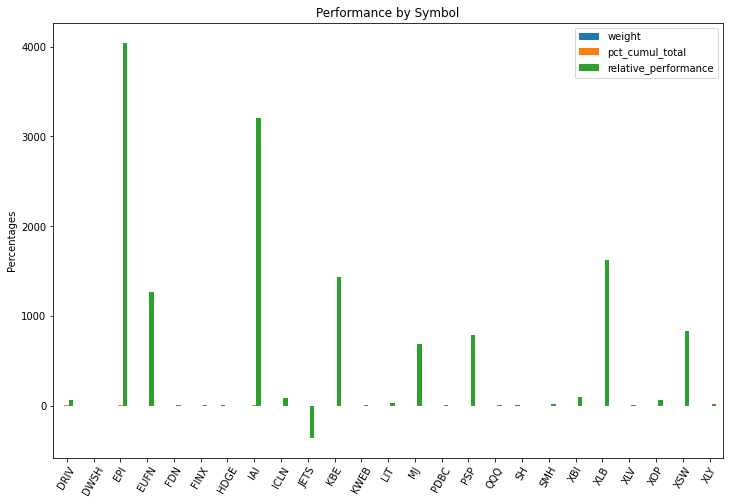

In [63]:
totals = portfolio.performance_per_symbol(weights['weight'].to_dict())
totals

,DRIV,DWSH,EPI,EUFN,FDN,FINX,HDGE,IAI,ICLN,JETS,...,PSP,QQQ,SH,SMH,XBI,XLB,XLV,XOP,XSW,XLY
DRIV,1.00,-0.55,0.59,0.61,0.44,0.61,-0.43,0.61,0.69,0.55,...,0.72,0.63,-0.82,0.71,0.33,0.69,0.44,0.55,0.63,0.79
DWSH,-0.55,1.00,-0.38,-0.79,0.32,-0.11,0.87,-0.66,-0.12,-0.89,...,-0.57,0.05,0.51,-0.11,-0.12,-0.57,-0.27,-0.88,-0.19,-0.30
EPI,0.59,-0.38,1.00,0.63,0.29,0.57,-0.32,0.44,0.32,0.53,...,0.78,0.47,-0.61,0.46,0.04,0.54,0.42,0.36,0.41,0.67
EUFN,0.61,-0.79,0.63,1.00,-0.18,0.23,-0.71,0.82,0.39,0.83,...,0.81,0.12,-0.65,0.26,0.03,0.73,0.46,0.68,0.21,0.50
FDN,0.44,0.32,0.29,-0.18,1.00,0.75,0.30,-0.07,0.50,-0.16,...,0.27,0.85,-0.44,0.62,0.31,0.12,0.20,-0.22,0.72,0.58
FINX,0.61,-0.11,0.57,0.23,0.75,1.00,-0.15,0.22,0.53,0.24,...,0.57,0.80,-0.64,0.71,0.35,0.33,0.36,0.09,0.80,0.68
HDGE,-0.43,0.87,-0.32,-0.71,0.30,-0.15,1.00,-0.53,-0.13,-0.82,...,-0.50,0.05,0.43,-0.08,-0.18,-0.46,-0.24,-0.67,-0.25,-0.21
IAI,0.61,-0.66,0.44,0.82,-0.07,0.22,-0.53,1.00,0.49,0.67,...,0.61,0.15,-0.68,0.34,0.19,0.77,0.53,0.63,0.31,0.51
ICLN,0.69,-0.12,0.32,0.39,0.50,0.53,-0.13,0.49,1.00,0.23,...,0.44,0.54,-0.60,0.59,0.35,0.54,0.38,0.16,0.60,0.59
JETS,0.55,-0.89,0.53,0.83,-0.16,0.24,-0.82,0.67,0.23,1.00,...,0.69,0.10,-0.58,0.21,0.06,0.60,0.31,0.74,0.31,0.38


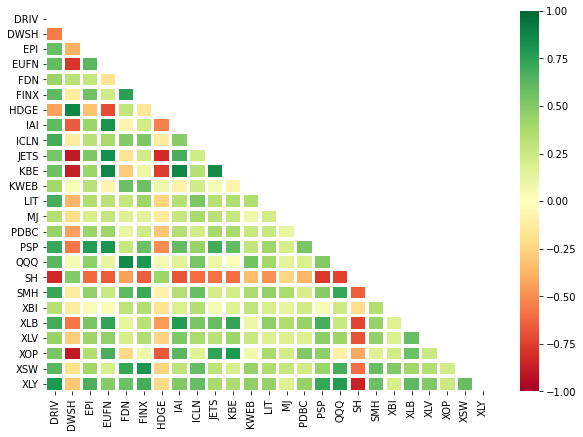

In [64]:
corr_df = portfolio.correlation_map(ts)
corr_df

In [65]:
benchmark = pf.Benchmark('SPY', capital, startdate_benchmark, end, use_adj=True)
benchmark.run()

2020-11-20 00:00:00 BUY  282 SPY @ 353.82
2021-01-26 00:00:00 SELL 282 SPY @ 383.79


In [66]:
benchmark.tlog, benchmark.dbal = benchmark.get_logs()

In [67]:
benchmark.stats = benchmark.get_stats()

/Users/moilanen/Dropbox (Personal)/notebooks/trading/pinkfish/statistics.py:526: RuntimeWarning: invalid value encountered in long_scalars
  stats['pct_profitable_years'] = (pc > 0).sum() / len(pc) * 100
/Users/moilanen/ws/pinkfish/examples/pandas_1.0/lib/python3.7/site-packages/numpy/lib/function_base.py:380: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis)
/Users/moilanen/ws/pinkfish/examples/pandas_1.0/lib/python3.7/site-packages/numpy/core/_methods.py:170: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


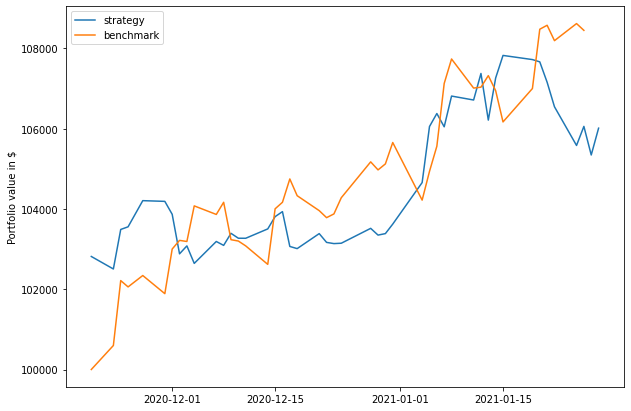

In [68]:
pf.plot_equity_curve(dbal, benchmark=benchmark.dbal)

In [69]:
df = pf.summary(stats, benchmark.stats, metrics=pf.currency_metrics)
df

,strategy,benchmark
beginning_balance,"$100,000.00","$100,000.00"
ending_balance,"$106,013.50","$108,451.04"
total_net_profit,"$5,617.22","$8,451.04"
gross_profit,"$13,584.06","$8,451.04"
gross_loss,"-$7,966.84",$0.00


,strategy,benchmark
annual_return_rate,27.08,55.62
max_closed_out_drawdown,-2.30,-1.49
drawdown_annualized_return,-0.08,-0.03
drawdown_recovery,-0.03,-0.02
best_month,4.52,4.58
worst_month,-0.81,0.83
sharpe_ratio,2.07,4.73
sortino_ratio,3.32,9.17
monthly_std,1.70,1.16
annual_std,NaN,NaN


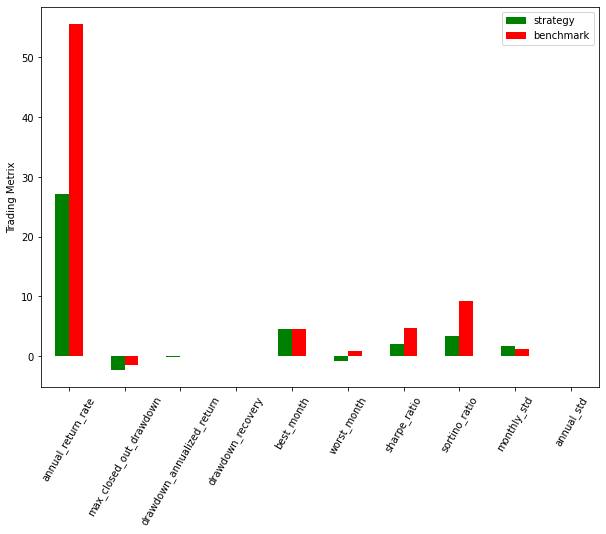

In [70]:
df = pf.plot_bar_graph(stats, benchmark.stats)
df

In [ ]:
from polygon import RESTClient
from dateutil import tz
def aggregates_to_df(resp):
    epoch = datetime(1601, 1, 1)
    df = pd.DataFrame(resp.results)
#     tz_ = tz.gettz('America/New_York')
    tz_ = tz.gettz('UTC')

    df.set_index(df['t'].apply(lambda x: datetime.fromtimestamp(x / 1000, tz=tz_)), inplace=True)
    df.rename(columns={"v": "volume", "o": "open", "c": "close", "h": "high", "l": "low"}, inplace=True)
    if 't' in df:
        df.drop(['t'], axis=1, inplace=True)
    if 'n' in df:
        df.drop(['n'], axis=1, inplace=True)

    del df.index.name

    return df

def history(symbol, start_date, timespan = 'day', multiplier = 1):
    date_format = "%Y-%m-%d"
    
    end_date = date.today() + timedelta(days = 7) # Polygon is exclusive on dates and must extend for a week
    client = RESTClient('WeYC_RTF_nZg3S_UKGI68lvNZ__8l6YM09p_Rg')

    
    try:
        resp = client.stocks_equities_aggregates(symbol, multiplier, timespan, start_date.strftime(date_format), end_date.strftime(date_format))
    except Exception as e:
        print("[history_aggregate()]: Polygon connection error: %s" % (str(e)))

    if resp.status != 'OK':
        raise ValueError("Polygon history_aggregate response not OK: %s" % (resp['status']))
        
    if resp.results == None or len(resp.results) == 0:
        raise ValueError("Polygon history_aggregate results are empty")
        
    df = aggregates_to_df(resp)
    
    return df

from datetime import datetime
from dateutil import tz
import pandas_market_calendars as mcal
import time
class Polygon():
    date_format = "%Y-%m-%d"
    approximate_holes_active = False
    def __init__(self):
        self.mcal = mcal.get_calendar('NYSE')
        self.client = RESTClient('WeYC_RTF_nZg3S_UKGI68lvNZ__8l6YM09p_Rg')
    
    def history_aggregate(self, symbol, bar_count, frequency, start = False, end = False, after_hours = False):
        max_timespan = 5000
        converts = {
            '1m': {
                'timespan': 'minute',
                'multiplier': 1,
                'per_day': 390.0,
                'max_days': math.floor(max_timespan / 390.0),
                'granularity_minutes': 1
            },
            '5m': {
                'timespan': 'minute',
                'multiplier': 5,
                'per_day': 390 / 5.0,
                'max_days': math.floor(max_timespan / (390.0 / 5.0)),
                'granularity_minutes': 5
            },
            '20m': {
                'timespan': 'minute',
                'multiplier': 20,
                'per_day': 390 / 20.0,
                'max_days': math.floor(max_timespan / (390.0)),
                'granularity_minutes': 20
            },
            '30m': {
                'timespan': 'minute',
                'multiplier': 30,
                'per_day': 390 / 30.0,
                'max_days': math.floor(max_timespan / (390.0)),
                'granularity_minutes': 30
            },
            '1h': {
                'timespan': 'hour',
                'multiplier': 1,
                'per_day': 6.5,
                'max_days': math.floor(max_timespan / 24),
                'granularity_minutes': 60
            },
            '1d': {
                'timespan': 'day',
                'multiplier': 1,
                'per_day': 1.0,
                'max_days': max_timespan,
                'granularity_minutes': 24 * 60
            },
            '1w': {
                'timespan': 'week',
                'multiplier': 1,
                'per_day': 1 / 5.0,
                'max_days': math.floor(max_timespan * 7),
                'granularity_minutes': 24 * 60 * 7
            },
        }

        convert = converts[frequency]
        multiplier = convert['multiplier']
        timespan = convert['timespan']
        max_days = convert['max_days']
        granularity_minutes = convert['granularity_minutes']

        incomplete = False

        if end is False:
            end = self.get_datetime()

        if start is False:
            # See how many days we span
            days = (bar_count / convert['per_day']) + 1.0 # Make sure we go over
            days = days * 1.15

            start = self.mcal.get_days_ago(end, int(days))

        wanted_times_all = self.wanted_times(start, end, granularity_minutes, timespan)
        wanted_times_last = wanted_times_all[-1]

        # Polygon is exclusive dates
        end = end + timedelta(days=1)
        need_data = True
        start_ = datetime(start.year, start.month, start.day, tzinfo=self.timezone())
        df_out = False
        attempts = 0

        # Pdb().set_trace()

        while need_data:
            if attempts == 0:
                end_ = min(end, (start_ + timedelta(days=max_days)))
            try:
#                 self.debug("[%s]: Calling start: %s end: %s Attempt: %d" % (symbol, str(start_), str(end_), attempts))
                resp = self.client.stocks_equities_aggregates(symbol, multiplier, timespan, start_.strftime(self.date_format), end_.strftime(self.date_format))
            except Exception as e:
                print("[history_aggregate()]: Polygon connection error: %s" % (str(e)))
                time.sleep(3)
                continue

            if resp.status != 'OK':
                raise ValueError("Polygon history_aggregate response not OK: %s" % (resp['status']))

            if resp.results == None or len(resp.results) == 0:
                #print("Empty Results: Start: %s End: %s" % (start_, end_))
                start_ = end_

                # This only happens if there is no data
                if start_ >= self.get_datetime():
                    # print("[%s]: No Data at all" % (symbol))
                    return df_out

                continue

            df = self.aggregates_to_df(resp)

            df_orig = df
            # print(str(df))
            if after_hours is False:
                # Pdb().set_trace()
                df = self.after_hours_remove(df, timespan)

            if df_out is False:
                df_out = df
            else:
                df_out = pd.concat([df_out, df], sort=True)
            df_out = df_out.loc[~df_out.index.duplicated(keep='first')]
            df_out = df_out.sort_index()

            wanted_times = self.wanted_times(start_, end_, granularity_minutes, timespan)

            missing = set(wanted_times).difference(df.index.to_list())
            if len(missing) > 0 and attempts < 1:
                first = min(missing)
                if start_ == first.to_pydatetime():

                    print("[%s] Missing[%d]: %s :: %s - %s :: Attempt: %d" % (symbol, len(missing), str(first), str(start_), str(end_), attempts))

                    # Try breaking the cache of polygon to get a different answer
                    #end_ = min(end, (start_ + timedelta(days=random.randint(1, 3))))
                    # start_ = first.to_pydatetime() - timedelta(days=random.randint(1, 3))
                    # print("[%s] Trying: %s - %s" % (symbol, str(start_), str(end_)))

                    attempts += 1
                    time.sleep(0.5 * attempts)
                else:
                    start_ = first.to_pydatetime()
                continue
            if len(missing) > 0 and attempts >= 1:
                incomplete = True
            if len(missing) > 0 and attempts >= 1 and self.approximate_holes_active is True:
                df_out = self.approximate_holes(df_out, missing, symbol)

            attempts = 0

            start_ = df_orig.iloc[-1].name.to_pydatetime()

            # print("%s :: %s" % (str(wanted_times_last.strftime(self.date_format)), str(start_.strftime(self.date_format))))
            # print("%s :: %s" % (str((end - timedelta(days=1)).strftime(self.date_format)), str(start_.strftime(self.date_format))))
            # if (end - timedelta(days=1)).strftime(self.date_format) == start_.strftime(self.date_format):
            if wanted_times_last.strftime(self.date_format) <= start_.strftime(self.date_format):
                need_data = False

        # Drop duplicates
        df_out = df_out.loc[~df_out.index.duplicated(keep='first')]

        missing_all = set(wanted_times_all).difference(df_out.index.to_list())
        if len(missing_all) > 0:
            # print("[%s] Missing Data: %s" % (symbol, str(len(missing_all))))
            pass

        if len(df_out) < bar_count:
            print("Polygon history_aggregate does not have enough data. Want: %d Have: %d DF: %s" % (bar_count, len(df_out), str(df_out)))
            # Pdb().set_trace()
            # raise ValueError("Polygon history_aggregate does not have enough data. Want: %d Have: %d DF: %s" % (bar_count, len(df), str(df)))

        return df_out.sort_index().iloc[-bar_count:,].dropna(how='all')


    def aggregates_to_df(self, resp):
        epoch = datetime(1601, 1, 1)
        df = pd.DataFrame(resp.results)
        tz = self.timezone()
        df.set_index(df['t'].apply(lambda x: datetime.fromtimestamp(x / 1000, tz=tz)), inplace=True)
        df.rename(columns={"v": "volume", "o": "open", "c": "close", "h": "high", "l": "low"}, inplace=True)
        if 't' in df:
            df.drop(['t'], axis=1, inplace=True)
        if 'n' in df:
            df.drop(['n'], axis=1, inplace=True)

#         del df.index.name

        return df
    
    def timezone(self):
        return tz.gettz('America/New_York')
    def get_datetime(self):
        return datetime.now(self.timezone())
    
    def wanted_times(self, start, end, delta, timespan):
        mcal = self.mcal
        out = []

        if end > self.get_datetime():
            end = self.get_datetime()

        convert = {
            'minute': 'min',
            'hour': 'hour',
            'day': 'D',
            'week': 'W'
        }

        dti_timespan = convert[timespan]

        schedule = mcal.schedule(start, end)
        schedule['market_open'] = schedule['market_open'].dt.tz_convert(self.timezone())
        schedule['market_close'] = schedule['market_close'].dt.tz_convert(self.timezone())

        for index, row in schedule.iterrows():

            day_start = row['market_open']
            if timespan in ['day', 'week']:
                day_start = day_start.replace(hour = 0, minute = 0, second = 0, microsecond = 0)
                if timespan == 'day':
                    td = timedelta(days=delta)
                else:
                    td = timedelta(days=(delta*7))
            else:
                td = timedelta(minutes=delta)
                day_start = row['market_open']
                if timespan == 'hour':
                    day_start = day_start.replace(hour = 9, minute = 0, second = 0, microsecond = 0)
                else:
                    minute = (30 % delta) + 30
                    day_start = day_start.replace(hour = 9, minute = minute, second = 0, microsecond = 0)

            if row['market_close'] > self.get_datetime():
                day_end = self.get_datetime() - timedelta(minutes = 1)
            else:
                day_end = row['market_close']

            dts = [pd.Timestamp(dt) for dt in self.datetime_range(day_start, day_end, td)]

            out = out + dts

        return out
    
    
    def datetime_range(self, start, end, delta):
        current = start
        while current < end:
            yield current
            current += delta
            
    def after_hours_remove(self, df, timespan):
        if timespan in ['day', 'week']:
            return df
        tz = self.timezone()
        if timespan == 'hour':
            df = df.between_time('9:00', '16:00', include_end = False)
        else:
            df = df.between_time('9:30', '16:00', include_start = True, include_end = False)

        if len(df) == 0:
            return pd.DataFrame()

        start_date = df.iloc[0].name
        end_date = df.iloc[-1].name
        delta = end_date - start_date
        days_between = delta.days
        assert days_between >= 0, "Unexpected order in after_hours_remove: %d" % (days_between)

        sched = self.mcal.schedule(end_date, days_between)
        early_closes = self.mcal.early_closes(sched)

        for index, row in early_closes.iterrows():
            # Premarket drops
            to_drop = df[df.index.date == index.date()].between_time('00:00', row['market_open'].astimezone(tz).to_pydatetime().replace(tzinfo=tz).time(), include_end = False)
            if len(to_drop):
                df = df.drop(to_drop.index)

            # After Hours
            to_drop = df[df.index.date == index.date()].between_time(row['market_close'].astimezone(tz).to_pydatetime().replace(tzinfo=tz).time(), '23:59:59', include_start = False)
            if len(to_drop):
                df = df.drop(to_drop.index)

        return df

